In [3]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import time

In [5]:
#Data preprocessing
dataset = pd.read_csv('train.csv')

X_train = dataset.drop(columns=['Target'])
y_train = dataset['Target']

ones = np.ones((X_train.shape[0], 1))
X_train = np.column_stack([ones, X_train.values])

x0 = np.array([-1.47, 0, 0, 0, 0])

In [6]:
def f_sum(x, U, v):
    dots = U @ x
    return np.sum((1 - v) * dots + np.logaddexp(0, -dots))

def grad_f_eval(x, U, v):
    g = 1/(1+np.exp(-U@x))
    return U.T @ (g-v)

In [6]:
# Task c.)
def gradient_method_const(f, x0, U, v, c=3e-5, epsilon=1e-3, max_iters=5_000_000):
    x = x0.astype(float).copy()
    k = 0
    x_iter = [x.copy()]
    f_val = [f(x, U, v)]
    while k < max_iters:
        grad = U.T @ (1/(1+np.exp(-U@x)) - v)
        if np.linalg.norm(grad) <= epsilon:
            break
        x -= c * grad
        k += 1
        x_iter.append(x.copy())
        f_val.append(f(x, U, v))

    f_val_check = all(f_val[i] >= f_val[i+1] for i in range(len(f_val)-1))
    print(f"Hodnota ucelovej funkcie nerastie: {f_val_check}")
    print(f"Pocet iteracii: {k}")

    return x, x_iter

print(f"\n--- c = 3e-7 ---")
start = time.time()
vysl_1_1 = gradient_method_const(f_sum, x0, X_train, y_train.values,
                                     c=3e-7)

elapsed = time.time() - start
print(f"Výsledok: {vysl_1_1[0]}")
print(f"Čas: {elapsed:.2f}s")

print(f"\n--- c = 3e-5 ---")
start = time.time()
vysl_1_2 = gradient_method_const(f_sum, x0, X_train, y_train.values,
                                     c=3e-5)

elapsed = time.time() - start
print(f"Výsledok: {vysl_1_2[0]}")
print(f"Čas: {elapsed:.2f}s")

print(f"\n--- c = 3e-3 ---")
start = time.time()
vysl_1_3 = gradient_method_const(f_sum, x0, X_train, y_train.values,
                                     c=3e-3)

elapsed = time.time() - start
print(f"Výsledok: {vysl_1_3[0]}")
print(f"Čas: {elapsed:.2f}s")


--- c = 3e-7 ---
Hodnota ucelovej funkcie nerastie: True
Pocet iteracii: 5000000
Výsledok: [-0.99398804  3.0594658   4.61121505  5.98086102  0.007168  ]
Čas: 136.48s

--- c = 3e-5 ---
Hodnota ucelovej funkcie nerastie: True
Pocet iteracii: 2736859
Výsledok: [-1.47360963e+00  3.07175527e+00  1.01989855e+01  1.76905539e+01
  4.84667713e-03]
Čas: 72.84s

--- c = 3e-3 ---
Hodnota ucelovej funkcie nerastie: False
Pocet iteracii: 5000000
Výsledok: [-7.89528871  8.27025728 22.63379642 48.20722059  5.6435618 ]
Čas: 138.12s


In [7]:
# Task d.)
def gradient_method_backtracking(f, x0, U, v, alpha=0.499, delta=0.8, epsilon=1e-3, max_iters=5_000_000):
    x = x0.astype(float).copy()
    k = 0

    x_iter = [x.copy()]
    l_min = np.inf
    l_max = np.nan

    while k < max_iters:
        grad = grad_f_eval(x, U, v)

        if np.linalg.norm(grad) <= epsilon:
            break

        d = -grad
        lambda_k = 0.2

        fx = f(x, U, v)
        dot = np.dot(grad, d) * alpha
        while f(x + lambda_k * d, U, v) > fx + dot * lambda_k:
            lambda_k *= delta

        if(k == 0):
            l_max = lambda_k

        x += lambda_k * d
        k += 1
        
        x_iter.append(x.copy())

        l_min = min(l_min, lambda_k)

    print(f"Pocet iteracii: {k}")
    print(f"lambda_min = {l_min}")
    print(f"lambda_max = {l_max}")

    return (x, x_iter, l_min, l_max)

start = time.time()
vysl_2 = gradient_method_backtracking(f_sum, x0, X_train, y_train.values)
elapsed = time.time() - start
print(f"Čas: {elapsed:.2f}s")
print(f"f_1 ma minimum priblizne v bode {vysl_2[0]} \n")
l_max, l_min = vysl_2[2], vysl_2[3]

Pocet iteracii: 631781
lambda_min = 5.575186299632669e-06
lambda_max = 6.9689828745408365e-06
Čas: 384.33s
f_1 ma minimum priblizne v bode [-1.47361099e+00  3.07175538e+00  1.01989574e+01  1.76906299e+01
  4.84665956e-03] 



In [8]:
# Tasks e.)
def golden_section(f, a, b, tol=1e-6):

    phi = (1 + np.sqrt(5))/2
    rho = phi - 1

    c1 = rho*a + (1 - rho)*b
    f1 = f(c1)
    c2 = (1 - rho)*a + rho*b
    f2 = f(c2)

    while abs(b - a) > tol:

        if f1 < f2:
            b = c2
            c2 = c1
            f2 = f1
            c1 = rho*a + (1 - rho)*b
            f1 = f(c1)
        else:
            a = c1
            c1 = c2
            f1 = f2
            c2 = (1 - rho)*a + rho*b
            f2 = f(c2)

    return (a+b)/2

def cauchy_method(f, x0, U, v, a, b, epsilon=1e-3, max_iters=5_000_000):
    x = x0.astype(float).copy()
    k = 0

    x_iter = [x.copy()]

    while k < max_iters:

        grad = grad_f_eval(x, U, v)
        d = -grad

        if np.linalg.norm(grad) <= epsilon:
            break

        def f_new(z):
            return f(x + z * d, U, v)

        lambda_k = golden_section(f_new, a, b)

        x = x + lambda_k * d
        x_iter.append(x.copy())

        k += 1

    print(f"Pocet iteracii: {k}")
    return x, x_iter
start = time.time()
vysl_3_1 = cauchy_method(f_sum, x0, X_train, y_train.values, 0.1*l_min, 10*l_max)
elapsed = time.time() - start
print(f"Čas: {elapsed:.2f}s")
print(f"f_1 ma minimum priblizne v bode {vysl_3_1[0]} \n")

start = time.time()
vysl_3_2 = cauchy_method(f_sum, x0, X_train, y_train.values, l_min, l_max)
elapsed = time.time() - start
print(f"Čas: {elapsed:.2f}s")
print(f"f_1 ma minimum priblizne v bode {vysl_3_2[0]} \n")

Pocet iteracii: 2547196
Čas: 471.59s
f_1 ma minimum priblizne v bode [-1.47364159e+00  3.07175376e+00  1.01976806e+01  1.76927373e+01
  4.84619853e-03] 

Pocet iteracii: 5000000
Čas: 305.05s
f_1 ma minimum priblizne v bode [-1.46249642e+00  3.06969473e+00  1.02376301e+01  1.71934336e+01
  4.94678893e-03] 



In [7]:
# Minimum
res = minimize(
    fun=lambda x: f_sum(x, X_train, y_train),
    x0=x0,
    method="BFGS"
)

# Results for c.) - e.)

x_opt_ref = res.x
x_opt_ref = np.array([-1.47377220e+00,  3.07173693e+00,  1.01906655e+01,  1.77027043e+01, 4.84402783e-03])
print("Referenčné riešenie:", x_opt_ref)

# # Constant step
# # Number of iterations: 2736859
# # Time: 1m 6.4s
x_1 = np.array([-1.47360963e+00,  3.07175527e+00,  1.01989855e+01,  1.76905539e+01, 4.84667713e-03])
x_12 = np.array([-0.99398804, 3.0594658, 4.61121505, 5.98086102, 0.007168])
x_13 = np.array([-7.89528871, 8.27025728, 22.63379642, 48.20722059, 5.6435618])
print(f"c\t\t   : {x_1}, chyba: {np.linalg.norm(x_1 - x_opt_ref)}\n")
print(f"c\t\t   : {x_12}, chyba: {np.linalg.norm(x_12 - x_opt_ref)}\n")
print(f"c\t\t   : {x_13}, chyba: {np.linalg.norm(x_13 - x_opt_ref)}\n")

# # Approximately optimal step
# # Number of iterations: 633840
# # Time: 3m 28.0s
x_2 = np.array([-1.47361102e+00,  3.07175538e+00,  1.01989558e+01,  1.76906325e+01, 4.84665901e-03])
print(f"d\t\t   : {x_2}, chyba: {np.linalg.norm(x_2 - x_opt_ref)} \n")

# # Golden section on [0.1*l_min, 10*l_max]
# # Number of iterations: 2472704
# # Time: 4m 6.8s
x_3 = np.array([-1.47363523e+00,  3.07175410e+00, 1.01979473e+01,  1.76922987e+01, 4.84631001e-03])
print(f"e\t\t   : {x_3}, chyba: {np.linalg.norm(x_3 - x_opt_ref)} \n")

# # Golden section on [l_min, l_max]
# # Number of iterations: 3000000 (max_iter)
# # Time: 1m 42.0s
x_4 = np.array([-1.47363523, 3.07175410, 10.1979473, 17.6922987, 0.00484631])
x_42 = np.array([-1.46249642, 3.06969473, 10.2376301, 17.1934336, 0.00494678893])
print(f"e\t\t   : {x_4}, chyba: {np.linalg.norm(x_4 - x_opt_ref)} \n")
print(f"e\t\t   : {x_42}, chyba: {np.linalg.norm(x_42 - x_opt_ref)} \n")
# # print(f"e\t\t   : {vysl_3_2[0]}, chyba: {np.linalg.norm(vysl_3_2[0] - x_opt_ref)} \n")


Referenčné riešenie: [-1.47377220e+00  3.07173693e+00  1.01906655e+01  1.77027043e+01
  4.84402783e-03]
c		   : [-1.47360963e+00  3.07175527e+00  1.01989855e+01  1.76905539e+01
  4.84667713e-03], chyba: 0.014726893512865089

c		   : [-0.99398804  3.0594658   4.61121505  5.98086102  0.007168  ], chyba: 12.990851628224819

c		   : [-7.89528871  8.27025728 22.63379642 48.20722059  5.6435618 ], chyba: 34.42982206475787

d		   : [-1.47361102e+00  3.07175538e+00  1.01989558e+01  1.76906325e+01
  4.84665901e-03], chyba: 0.014645263932344917 

e		   : [-1.47363523e+00  3.07175410e+00  1.01979473e+01  1.76922987e+01
  4.84631001e-03], chyba: 0.012701188267173343 

e		   : [-1.47363523e+00  3.07175410e+00  1.01979473e+01  1.76922987e+01
  4.84631000e-03], chyba: 0.012701188267171546 

e		   : [-1.46249642e+00  3.06969473e+00  1.02376301e+01  1.71934336e+01
  4.94678893e-03], chyba: 0.5115600100544843 



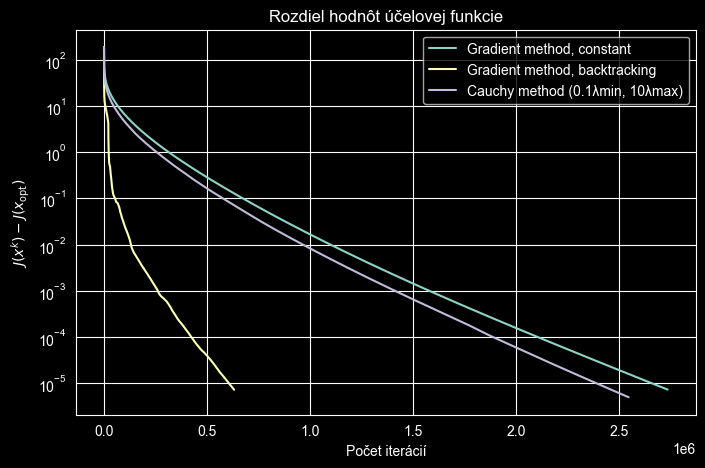

In [10]:
def compute_cost_differences(f, X_train, y_train, x_opt, results, eps=1e-15):
    J_opt = f(x_opt, X_train, y_train)

    diffs_all = []

    for result in results:
        result = np.array(result)
        diffs = []

        for x_k in result:
            J_x_k = f(x_k, X_train, y_train)
            diffs.append(J_x_k - J_opt)

        diffs = np.array(diffs)
        diffs = np.maximum(diffs, eps)
        diffs_all.append(diffs)

    return diffs_all

def plot_cost_differences_precomputed(diffs_all):
    labels = [
        "Gradient method, constant",
        "Gradient method, backtracking",
        "Cauchy method (0.1λmin, 10λmax)"
    ]

    styles = ["-", "-", "-"]

    plt.figure(figsize=(8, 5))

    for diffs, label, style in zip(diffs_all, labels, styles):
        plt.semilogy(diffs, linestyle=style, label=label)

    plt.xlabel("Počet iterácií")
    plt.ylabel(r"$J(x^k) - J(x_{\mathrm{opt}})$")
    plt.title("Rozdiel hodnôt účelovej funkcie")
    plt.grid(True, which="major")
    plt.legend()
    plt.show()

results = [
    np.array(vysl_1_2[1]),
    np.array(vysl_2[1]),
    np.array(vysl_3_1[1]),
]

diffs_all = compute_cost_differences(
    f_sum,
    X_train,
    y_train,
    x_opt_ref,
    results
)

plot_cost_differences_precomputed(diffs_all)

In [11]:
#downloading test data
dataset_test = pd.read_csv('test.csv')

X_test = dataset_test.drop(columns=['Target'])
y_test = dataset_test['Target']

ones = np.ones((X_test.shape[0], 1))
X_test = np.column_stack([ones, X_test.values])

#const gradient c = 3e-5
x_const = np.array([-1.47360963, 3.07175527, 10.1989855, 17.6905539, 0.00484668]).reshape((5,1))

# classification function
def predict(X, w):
    return (1 / (1 + np.exp(-(X@w))) > 0.5).astype(int)

#metric
def accuracy(y_pred, y_true):
    return (np.sum(y_pred == y_true) / len(y_pred))*100

#Predictions on the test set
y_pred_test = predict(X_test, x_const)
print("Accuracy najlepšej metódy", accuracy(y_pred_test, y_test.to_numpy().reshape(y_pred_test.shape)), "%")
print(f"Počet správne klasifikovaných {np.sum(y_pred_test == y_test.to_numpy().reshape(y_pred_test.shape))} zo {len(y_test)}")

#Worst method prediction (const gradient c=3e-3)
x_worst = [-7.89528871, 8.27025728, 22.63379642, 48.20722059, 5.6435618]
y_pred_test_worst = predict(X_test, x_worst)
print("Accuracy najhoršej metódy", accuracy(y_pred_test_worst, y_test.to_numpy().reshape(y_pred_test_worst.shape)), "%")
print(f"Počet správne klasifikovaných {np.sum(y_pred_test_worst == y_test.to_numpy().reshape(y_pred_test_worst.shape))} zo {len(y_test)}")

Accuracy najlepšej metódy 88.67924528301887 %
Počet správne klasifikovaných 47 zo 53
Accuracy najhoršej metódy 64.15094339622641 %
Počet správne klasifikovaných 34 zo 53
